# PCA (Principal Component Analysis)

In [139]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Class 0
np.random.seed(23)
mu_vec1 = np.array([0,0,0])
mu_cov1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
df1 = np.random.multivariate_normal(mu_vec1, mu_cov1, 20)
df1 = pd.DataFrame(df1, columns = ['feature1','feature2','feature3'])
df1['Target'] = 0

# Class 1
mu_vec2 = np.array([1,1,1])
mu_cov2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
df2 = np.random.multivariate_normal(mu_vec2, mu_cov2,20)
df2 = pd.DataFrame(df2, columns = ['feature1','feature2','feature3'])
df2['Target'] = 1

df = pd.concat([df1,df2],ignore_index= True)
df = df.sample(40).reset_index()
df = df.drop(columns = ['index'])
df

,feature1,feature2,feature3,Target
0,-0.367548,-1.137460,-1.322148,0
1,0.177061,-0.598109,1.226512,1
2,0.420623,0.411620,-0.071324,0
3,1.968435,-0.547788,-0.679418,0
4,-2.506230,0.146960,0.606195,0
5,1.425140,1.441152,0.182561,1
6,2.224431,0.230401,1.192120,1
7,0.322272,0.060343,-1.043450,0
8,-0.723253,1.461259,-0.085367,1
9,2.823378,-0.332863,2.637391,1


In [140]:
import plotly.express as px
fig = px.scatter_3d(df, df['feature1'],df['feature2'], df['feature3'], color  = df['Target'])
fig.update_traces(marker = dict(size = 7, line = dict(width = 2, color = 'DarkSlateGrey')), selector = dict(mode = 'markers'))
fig.show()

In [141]:
# Step 1 : Apply Standard Scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

In [142]:
# Step 2 :  Find Covarience Matrix
covariance_matrix = np.cov([df.iloc[:,0], df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix: \n',covariance_matrix)

Covariance Matrix: 
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [143]:
# Step 3 : Find Eigen Values and Eigen Vectors
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [144]:
eigen_values

array([1.3536065 +0.j, 0.94557084+0.j, 0.77774573+0.j])

In [145]:
eigen_vectors

array([[-0.53875915+0.j, -0.69363291+0.j,  0.47813384+0.j],
       [-0.65608325+0.j, -0.01057596+0.j, -0.75461442+0.j],
       [-0.52848211+0.j,  0.72025103+0.j,  0.44938304+0.j]])

d:\scikit-learn.py\.venv\Lib\site-packages\matplotlib\transforms.py:1913: ComplexWarning: Casting complex values to real discards the imaginary part
  return affine_transform(values, mtx)


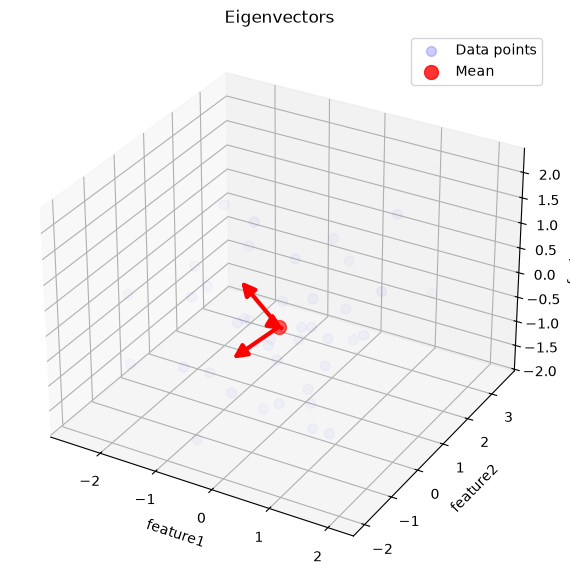

In [146]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch


class Arrow3D(FancyArrowPatch):

    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self):
        xs3d, ys3d, zs3d = self._verts3d

        xs, ys, zs = proj3d.proj_transform(
            xs3d, ys3d, zs3d,
            self.axes.get_proj()
        )

        self.set_positions(
            (xs[0], ys[0]),
            (xs[1], ys[1])
        )

        return np.min(zs)


# -------------------------------
# Create figure
# -------------------------------

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')


# -------------------------------
# Plot data points
# -------------------------------

ax.scatter(
    df['feature1'],
    df['feature2'],
    df['feature3'],
    s=50,
    color='blue',
    alpha=0.2,
    label='Data points'
)


# -------------------------------
# Calculate mean
# -------------------------------

mean_x = df['feature1'].mean()
mean_y = df['feature2'].mean()
mean_z = df['feature3'].mean()


# Plot mean point
ax.scatter(
    mean_x,
    mean_y,
    mean_z,
    s=100,
    color='red',
    alpha=0.8,
    label='Mean'
)


# -------------------------------
# Plot eigenvectors
# -------------------------------

for v in eigen_vectors.T:

    arrow = Arrow3D(
        [mean_x, mean_x + v[0]],
        [mean_y, mean_y + v[1]],
        [mean_z, mean_z + v[2]],
        mutation_scale=20,
        lw=3,
        arrowstyle="-|>",
        color="red"
    )

    ax.add_artist(arrow)


# -------------------------------
# Labels
# -------------------------------

ax.set_xlabel('feature1')
ax.set_ylabel('feature2')
ax.set_zlabel('feature3')

ax.set_title('Eigenvectors')

ax.legend()

plt.show()

In [ ]:

pc = eigen_vectors[0:2]


array([[-0.53875915+0.j, -0.69363291+0.j,  0.47813384+0.j],
       [-0.65608325+0.j, -0.01057596+0.j, -0.75461442+0.j]])

In [148]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# 40,3 - 3,2
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['Target'].values
new_df.head()

,PC1,PC2,target
0,0.599433+0.000000j,1.795862+0.000000j,0
1,1.056919+0.000000j,-0.212737+0.000000j,1
2,-0.271876+0.000000j,0.498222+0.000000j,0
3,-0.621586+0.000000j,0.023110+0.000000j,0
4,1.567286+0.000000j,1.730967+0.000000j,0


In [149]:
import numpy as np
import pandas as pd
import plotly.express as px

# --------------------------------
# 1. Features select karo
# --------------------------------

X = df[['feature1', 'feature2', 'feature3']].values


# --------------------------------
# 2. Mean centering
# --------------------------------

X_mean = X.mean(axis=0)

X_centered = X - X_mean


# --------------------------------
# 3. Covariance matrix
# --------------------------------

covariance_matrix = np.cov(
    X_centered,
    rowvar=False
)

print("Covariance Matrix:")
print(covariance_matrix)


# --------------------------------
# 4. Eigenvalues & Eigenvectors
# --------------------------------

eigen_values, eigen_vectors = np.linalg.eigh(
    covariance_matrix
)


# --------------------------------
# 5. Eigenvalues ko descending order
# --------------------------------

sorted_index = np.argsort(eigen_values)[::-1]

eigen_values = eigen_values[sorted_index]
eigen_vectors = eigen_vectors[:, sorted_index]


print("\nEigenvalues:")
print(eigen_values)

print("\nEigenvectors:")
print(eigen_vectors)


# --------------------------------
# 6. Principal Components
# --------------------------------

principal_components = X_centered @ eigen_vectors


# --------------------------------
# 7. New DataFrame
# --------------------------------

new_df = pd.DataFrame(
    principal_components,
    columns=['PC1', 'PC2', 'PC3']
)


# --------------------------------
# 8. Target add karo
# --------------------------------

new_df['target'] = df['Target'].values


# --------------------------------
# 9. Ensure real float values
# --------------------------------

new_df['PC1'] = np.real(new_df['PC1']).astype(float)
new_df['PC2'] = np.real(new_df['PC2']).astype(float)
new_df['PC3'] = np.real(new_df['PC3']).astype(float)

new_df['target'] = new_df['target'].astype(str)


print("\nNew DataFrame:")
print(new_df.head())

print("\nData types:")
print(new_df.dtypes)


# --------------------------------
# 10. PC1 vs PC2 visualization
# --------------------------------

fig = px.scatter(
    new_df,
    x='PC1',
    y='PC2',
    color='target',
    color_discrete_sequence=px.colors.qualitative.G10
)


fig.update_traces(
    marker=dict(
        size=12,
        line=dict(
            width=2,
            color='DarkSlateGrey'
        )
    )
)


fig.update_layout(
    title='PCA: PC1 vs PC2',
    xaxis_title='Principal Component 1',
    yaxis_title='Principal Component 2'
)


fig.show()

Covariance Matrix:
[[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]

Eigenvalues:
[1.3536065  0.94557084 0.77774573]

Eigenvectors:
[[-0.53875915 -0.69363291  0.47813384]
 [-0.65608325 -0.01057596 -0.75461442]
 [-0.52848211  0.72025103  0.44938304]]

New DataFrame:
        PC1       PC2       PC3 target
0  2.302877 -0.757593  0.030108      0
1  0.524464  0.520221  0.876160      1
2  0.380275 -0.459443 -0.261986      0
3  0.534262 -1.773773  0.836139      0
4  1.610434  1.747819 -1.027681      0

Data types:
PC1       float64
PC2       float64
PC3       float64
target        str
dtype: object
